In [ ]:
!ls

Mineral_Identification_Project.7z  sample_data


In [ ]:
!apt-get install -y p7zip-full

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [ ]:
!7z x Mineral_Identification_Project.7z -o/content/Mineral_Identification_Project


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 803616676 bytes (767 MiB)

Extracting archive: Mineral_Identification_Project.7z
--
Path = Mineral_Identification_Project.7z
Type = 7z
Physical Size = 803616676
Headers Size = 68052
Method = LZMA:23
Solid = +
Blocks = 1

  0%      0% - Mineral_Identification_Project/check_dataset.py                                                        0% 50 - Mineral_Identification_Project/test/biotite/C1_01__798.jpg                                                                    

In [ ]:
import os

print(os.listdir('/content/Mineral_Identification_Project'))

['Mineral_Identification_Project']


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!find /content/Mineral_Identification_Project -type d | head -30

/content/Mineral_Identification_Project
/content/Mineral_Identification_Project/Mineral_Identification_Project
/content/Mineral_Identification_Project/Mineral_Identification_Project/test
/content/Mineral_Identification_Project/Mineral_Identification_Project/test/chrysocolla
/content/Mineral_Identification_Project/Mineral_Identification_Project/test/bornite
/content/Mineral_Identification_Project/Mineral_Identification_Project/test/malachite
/content/Mineral_Identification_Project/Mineral_Identification_Project/test/biotite
/content/Mineral_Identification_Project/Mineral_Identification_Project/test/pyrite
/content/Mineral_Identification_Project/Mineral_Identification_Project/test/muscovite
/content/Mineral_Identification_Project/Mineral_Identification_Project/test/quartz
/content/Mineral_Identification_Project/Mineral_Identification_Project/train
/content/Mineral_Identification_Project/Mineral_Identification_Project/train/chrysocolla
/content/Mineral_Identification_Project/Mineral_Ident

In [ ]:
# ── Step 1: Dataset Paths ──────────────────────────────

import os

import os

DATASET_PATH = "/content/Mineral_Identification_Project/Mineral_Identification_Project"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

# Quick sanity check
for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    classes = os.listdir(split)
    print(f'{split}: {len(classes)} classes → {sorted(classes)}')

/content/Mineral_Identification_Project/Mineral_Identification_Project/train: 7 classes → ['biotite', 'bornite', 'chrysocolla', 'malachite', 'muscovite', 'pyrite', 'quartz']
/content/Mineral_Identification_Project/Mineral_Identification_Project/val: 7 classes → ['biotite', 'bornite', 'chrysocolla', 'malachite', 'muscovite', 'pyrite', 'quartz']
/content/Mineral_Identification_Project/Mineral_Identification_Project/test: 7 classes → ['biotite', 'bornite', 'chrysocolla', 'malachite', 'muscovite', 'pyrite', 'quartz']


In [ ]:
# ── Step 2: Imports & config ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS_HEAD = 10
EPOCHS_FINE = 10
NUM_CLASSES = 7
SEED        = 42
CLASS_NAMES = ['biotite','bornite','chrysocolla','malachite','muscovite','pyrite','quartz']

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Step 3: Data generators ──────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print('Train samples:', train_gen.samples)
print('Val   samples:', val_gen.samples)
print('Test  samples:', test_gen.samples)

Found 3959 images belonging to 7 classes.
Found 954 images belonging to 7 classes.
Found 727 images belonging to 7 classes.
Train samples: 3959
Val   samples: 954
Test  samples: 727


In [ ]:
# ── Step 4: Build model ──────────────────────────────────────────────────
def build_model(num_classes, trainable_backbone=False):
    base = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = trainable_backbone
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = build_model(NUM_CLASSES, trainable_backbone=False)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,839 (10.01 MB)

 Trainable params: 364,295 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
# ── Step 5: Phase 1 — Train head only ───────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

cb1 = [
    EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_mineral_model.keras', save_best_only=True, verbose=1),
]

print('=== PHASE 1: Training head ===')
hist1 = model.fit(train_gen, epochs=EPOCHS_HEAD, validation_data=val_gen, callbacks=cb1)

=== PHASE 1: Training head ===
Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.3947 - loss: 1.7740
Epoch 1: val_loss improved from None to 1.01329, saving model to best_mineral_model.keras

Epoch 1: finished saving model to best_mineral_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.4736 - loss: 1.5049 - val_accuracy: 0.6667 - val_loss: 1.0133 - learning_rate: 0.0010
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.5950 - loss: 1.1357
Epoch 2: val_loss improved from 1.01329 to 0.87885, saving model to best_mineral_model.keras

Epoch 2: finished saving model to best_mineral_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 95s 764ms/step - accuracy: 0.5994 - loss: 1.1254 - val_accuracy: 0.7191 - val_loss: 0.8788 - learning_rate: 0.0010
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.6477 - loss: 0.9966
Epoch 3: val_loss improved from 0.87885 to 0.77185, saving model to best_mineral_model.keras

Epoch 3: finished savi

In [ ]:
# ── Step 6: Phase 2 — Fine-tune top 30 backbone layers ──────────────────
base_model = model.layers[1]
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

cb2 = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_mineral_model.keras', save_best_only=True, verbose=1),
]

print('=== PHASE 2: Fine-tuning ===')
hist2 = model.fit(train_gen, epochs=EPOCHS_FINE, validation_data=val_gen, callbacks=cb2)

=== PHASE 2: Fine-tuning ===
Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.6992 - loss: 0.8571
Epoch 1: val_loss improved from None to 0.62262, saving model to best_mineral_model.keras

Epoch 1: finished saving model to best_mineral_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 129s 898ms/step - accuracy: 0.7179 - loss: 0.8212 - val_accuracy: 0.7757 - val_loss: 0.6226 - learning_rate: 1.0000e-04
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.7602 - loss: 0.7018
Epoch 2: val_loss did not improve from 0.62262
124/124 ━━━━━━━━━━━━━━━━━━━━ 95s 762ms/step - accuracy: 0.7626 - loss: 0.6878 - val_accuracy: 0.7778 - val_loss: 0.6619 - learning_rate: 1.0000e-04
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.7940 - loss: 0.5977
Epoch 3: val_loss did not improve from 0.62262
124/124 ━━━━━━━━━━━━━━━━━━━━ 93s 753ms/step - accuracy: 0.7984 - loss: 0.6006 - val_accuracy: 0.7851 - val_loss: 0.6527 - learning_rate: 1.0000e-04
Epoch 4/10
124/124

In [ ]:
# ── Step 7: Evaluate on test set ─────────────────────────────────────────
model.load_weights('best_mineral_model.keras')
loss, acc = model.evaluate(test_gen)
print(f'\n✅ Test Accuracy: {acc*100:.2f}%')

test_gen.reset()
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 429ms/step - accuracy: 0.8542 - loss: 0.5647

✅ Test Accuracy: 85.42%
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 485ms/step
              precision    recall  f1-score   support

     biotite       0.86      0.92      0.89       133
     bornite       0.77      0.41      0.54        73
 chrysocolla       0.96      0.82      0.89        85
   malachite       0.97      0.95      0.96        73
   muscovite       0.67      0.63      0.65        49
      pyrite       0.81      0.98      0.89       157
      quartz       0.87      0.92      0.89       157

    accuracy                           0.85       727
   macro avg       0.85      0.81      0.82       727
weighted avg       0.85      0.85      0.85       727



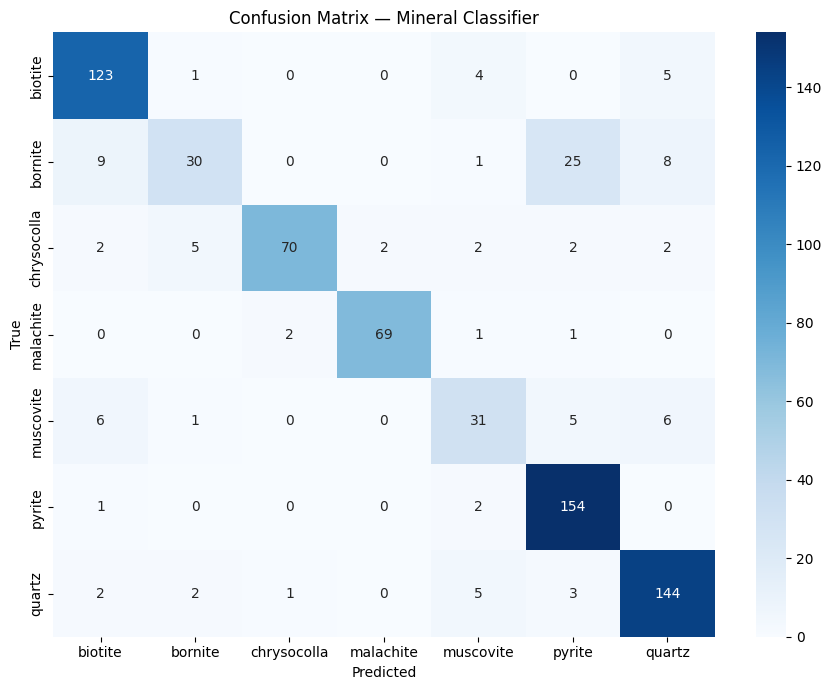

In [ ]:
# ── Step 8: Confusion matrix ─────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Mineral Classifier')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

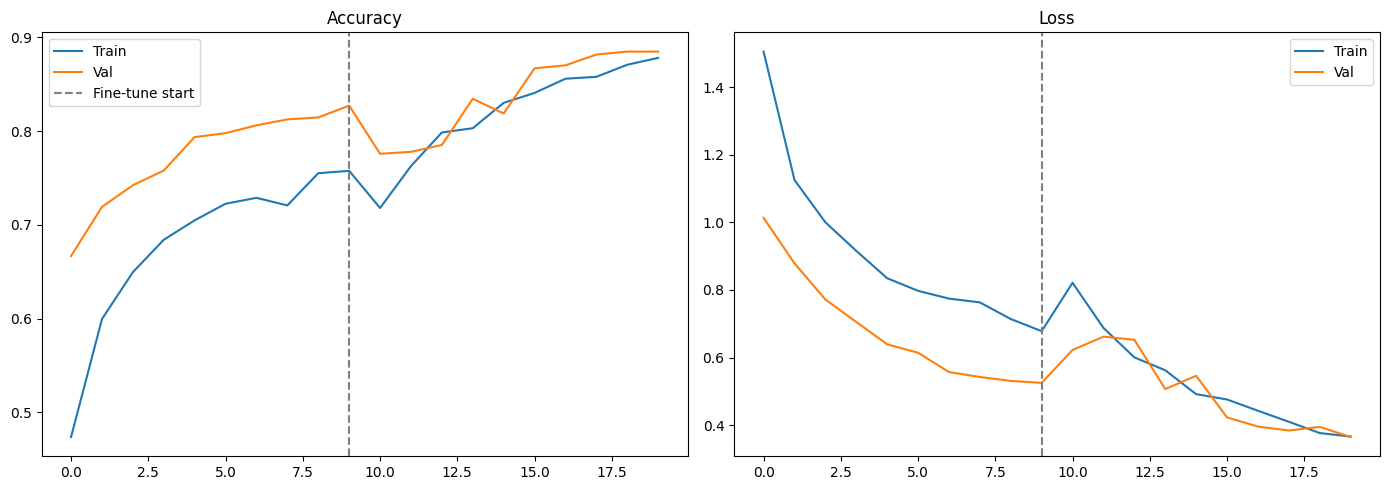

In [ ]:
# ── Step 9: Training curves ──────────────────────────────────────────────
def merge(h1, h2):
    return {k: h1.history[k]+h2.history[k] for k in h1.history}

hist = merge(hist1, hist2)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(hist['accuracy'], label='Train'); axes[0].plot(hist['val_accuracy'], label='Val')
axes[0].axvline(EPOCHS_HEAD-1, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(hist['loss'], label='Train'); axes[1].plot(hist['val_loss'], label='Val')
axes[1].axvline(EPOCHS_HEAD-1, color='gray', linestyle='--')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# ── Step 10: Predict a single image ──────────────────────────────────────
from tensorflow.keras.preprocessing import image as kimage

def predict_mineral(image_path):
    img = kimage.load_img(image_path, target_size=IMG_SIZE)
    arr = kimage.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    for i in np.argsort(probs)[::-1][:3]:
        print(f'  {CLASS_NAMES[i]:>15s}  {probs[i]*100:5.1f}%')

# predict_mineral('/content/drive/MyDrive/test_image.jpg')